In [1]:
# 第2章｜常用財報指標：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 常用財報指標

**對應影片**：第 2 章 單元 7「常用財報指標」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 從資產負債表、損益表的原始科目自己拼出幾十個指標，還要處理同一科目的不同名稱 | FinLab 已整理好：`financial_statement:*` 是統一名稱的財報科目，`fundamental_features:*` 是算好的財務指標 |
| `from finlab.ml import fundamental_features` | `data.get('fundamental_features:ROE稅後')` 一次取一個指標 |

這個單元先學會自己從財報算指標，再認識 FinLab 算好的指標，最後把指標拿來選股。

In [2]:
import pandas as pd
from finlab.backtest import sim

## 1. 自己從財報算指標

財報科目的 index 是季度（例如 `2018-Q3`），每一格是該季的數字。

In [3]:
revenue = data.get('financial_statement:營業收入淨額')
gross_profit = data.get('financial_statement:營業毛利')
operating_income = data.get('financial_statement:營業利益')

revenue['2330'].tail()

date
2017-Q3    252107345.0
2017-Q4    277570284.0
2018-Q1    248078671.0
2018-Q2    233276811.0
2018-Q3    260347882.0
Name: 2330, dtype: float64

三個最常用的指標：

- **營業毛利率** = 營業毛利 ÷ 營業收入：產品本身賺不賺錢。
- **營業利益率** = 營業利益 ÷ 營業收入：扣掉營業費用後還剩多少。
- **營收成長率** = 本季營收 ÷ 去年同季營收 − 1：和去年同一季比，避開季節性。

In [4]:
QUARTERS_PER_YEAR = 4

my_indicators = pd.DataFrame({
    '營業毛利率': (gross_profit / revenue * 100)['2330'],
    '營業利益率': (operating_income / revenue * 100)['2330'],
    '營收成長率': (revenue.pct_change(QUARTERS_PER_YEAR) * 100)['2330'],
})
my_indicators.tail()

,營業毛利率,營業利益率,營收成長率
date,,,
2017-Q3,49.929795,38.894715,-3.186771
2017-Q4,49.974862,39.231505,5.851044
2018-Q1,50.377041,39.030742,6.055322
2018-Q2,47.835061,36.192258,9.081658
2018-Q3,47.390761,36.583813,3.268662


## 2. FinLab 算好的財務指標

`fundamental_features` 收錄獲利能力、成長率、償債能力、經營效率等常用指標：

In [5]:
feature_names = data.search('fundamental_features').str.split(':').str[1]
print(f'共 {len(feature_names)} 個指標：')
print('、'.join(feature_names))

共 53 個指標：
營業利益、EBITDA、營運現金流、歸屬母公司淨利、折舊、流動資產、流動負債、取得不動產廠房及設備、經常稅後淨利、ROA稅後息前、ROA綜合損益、ROE稅後、ROE綜合損益、稅前息前折舊前淨利率、營業毛利率、營業利益率、稅前淨利率、稅後淨利率、業外收支營收率、貝里比率、營業費用率、推銷費用率、管理費用率、研究發展費用率、現金流量比率、稅率、每股營業額、每股營業利益、每股現金流量、每股稅前淨利、每股綜合損益、每股稅後淨利、總負債除總淨值、負債比率、淨值除資產、營收成長率、營業毛利成長率、營業利益成長率、稅前淨利成長率、稅後淨利成長率、經常利益成長率、資產總額成長率、淨值成長率、流動比率、速動比率、利息支出率、營運資金、總資產週轉次數、應收帳款週轉率、存貨週轉率、固定資產週轉次數、淨值週轉率次數、自由現金流量


和自己算的比較，數字一致：

In [6]:
finlab_indicators = pd.DataFrame({
    name: data.get(f'fundamental_features:{name}')['2330'] for name in my_indicators.columns
})
finlab_indicators.tail()

,營業毛利率,營業利益率,營收成長率
date,,,
2017-Q3,49.929795,38.894715,-3.186771
2017-Q4,49.974862,39.231505,5.851044
2018-Q1,50.377041,39.030742,6.055322
2018-Q2,47.835061,36.192258,9.081658
2018-Q3,47.390761,36.583813,3.268662


## 3. 季報和日資料一起用

季報公布後才看得到，所以要用「公布日」對齊股價：
`index_str_to_date()` 把季度轉成實際公布日期，`reindex(close.index, method='ffill')` 讓每個交易日都拿到當時最新一季的數字。

In [7]:
close = data.get('price:收盤價')
roe = data.get('fundamental_features:ROE稅後')

daily_roe = roe.index_str_to_date().reindex(close.index, method='ffill')
daily_roe[['2330', '2317', '2454']].tail()

symbol,2330,2317,2454
date,,,
2018-12-24,5.811125,1.904373,2.584514
2018-12-25,5.811125,1.904373,2.584514
2018-12-26,5.811125,1.904373,2.584514
2018-12-27,5.811125,1.904373,2.584514
2018-12-28,5.811125,1.904373,2.584514


## 4. 用財報指標選股：高 ROE vs 低 ROE

每月月底，在成交量夠大的股票中，買 ROE 最高（或最低）的 `N_STOCKS` 檔，等權重持有到下個月底。
`FinlabDataFrame` 運算時會自動對齊季報與日資料，所以可以直接把 `roe` 和成交量放在同一個條件裡。

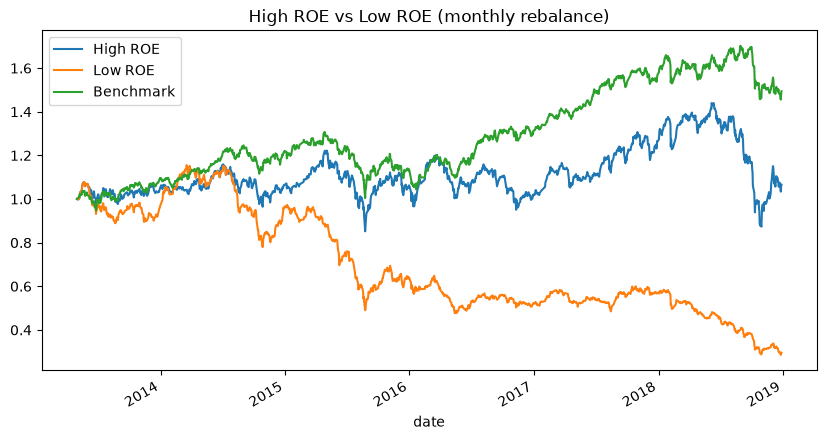

In [8]:
N_STOCKS = 30
LIQUIDITY_WINDOW = 20
MIN_AVG_VOLUME_SHARES = 500_000

liquid = data.get('price:成交股數').average(LIQUIDITY_WINDOW) > MIN_AVG_VOLUME_SHARES
liquid_roe = roe[liquid]

reports = {
    'High ROE': sim(liquid_roe.is_largest(N_STOCKS), resample='ME', name='High ROE'),
    'Low ROE': sim(liquid_roe.is_smallest(N_STOCKS), resample='ME', name='Low ROE'),
}

curves = pd.DataFrame({name: report.creturn for name, report in reports.items()})
benchmark = reports['High ROE'].benchmark.reindex(curves.index)
curves['Benchmark'] = benchmark / benchmark.dropna().iloc[0]
curves.plot(figsize=(10, 5), title='High ROE vs Low ROE (monthly rebalance)');

In [9]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in reports.items()
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
High ROE,1.13%,-39.34%,0.06
Low ROE,-19.38%,-75.28%,-1.10


一個指標就能把股票分成表現不同的兩群，這就是「因子」。
第 3 章會把幾十個財報指標一起交給機器學習模型，讓模型自己找出組合方式。